<a href="https://colab.research.google.com/github/Dhushyanthan005/day-1-datascience-question1/blob/main/energy_demand_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
df = pd.read_csv("datos_modelo.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (35039, 33)


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Columns:
['timestamp', 'active_power_mw', 'apparent_temperature_c', 'cloud_cover_percent', 'month', 'hour', 'is_holiday', 'is_weekend', 'is_school_vacation', 'active_power_lag_1h', 'active_power_lag_2h', 'active_power_lag_3h', 'active_power_lag_4h', 'active_power_lag_5h', 'active_power_lag_6h', 'active_power_lag_7h', 'active_power_lag_8h', 'active_power_lag_9h', 'active_power_lag_10h', 'active_power_lag_11h', 'active_power_lag_12h', 'active_power_lag_13h', 'active_power_lag_14h', 'active_power_lag_15h', 'active_power_lag_16h', 'active_power_lag_17h', 'active_power_lag_18h', 'active_power_lag_19h', 'active_power_lag_20h', 'active_power_lag_21h', 'active_power_lag_22h', 'active_power_lag_23h', 'active_power_lag_24h']

First 5 rows:


,timestamp,active_power_mw,apparent_temperature_c,cloud_cover_percent,month,hour,is_holiday,is_weekend,is_school_vacation,active_power_lag_1h,...,active_power_lag_15h,active_power_lag_16h,active_power_lag_17h,active_power_lag_18h,active_power_lag_19h,active_power_lag_20h,active_power_lag_21h,active_power_lag_22h,active_power_lag_23h,active_power_lag_24h
0,2/1/21 1:00,1508.726498,22.100000,21.766667,1,1,0,1,0,1569.519607,...,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065,1575.752549,1629.903638,1674.169500,1703.356546
1,2/1/21 2:00,1474.224972,21.803333,26.833333,1,2,0,1,0,1508.726498,...,1492.911710,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065,1575.752549,1629.903638,1674.169500
2,2/1/21 3:00,1448.436605,21.633333,22.300000,1,3,0,1,0,1474.224972,...,1481.049047,1492.911710,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065,1575.752549,1629.903638
3,2/1/21 4:00,1426.507838,21.223333,25.766667,1,4,0,1,0,1448.436605,...,1484.485208,1481.049047,1492.911710,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065,1575.752549
4,2/1/21 5:00,1419.126334,21.003333,17.533333,1,5,0,1,0,1426.507838,...,1466.621504,1484.485208,1481.049047,1492.911710,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065


In [ ]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
timestamp                 0
active_power_mw           0
apparent_temperature_c    0
cloud_cover_percent       0
month                     0
hour                      0
is_holiday                0
is_weekend                0
is_school_vacation        0
active_power_lag_1h       0
active_power_lag_2h       0
active_power_lag_3h       0
active_power_lag_4h       0
active_power_lag_5h       0
active_power_lag_6h       0
active_power_lag_7h       0
active_power_lag_8h       0
active_power_lag_9h       0
active_power_lag_10h      0
active_power_lag_11h      0
active_power_lag_12h      0
active_power_lag_13h      0
active_power_lag_14h      0
active_power_lag_15h      0
active_power_lag_16h      0
active_power_lag_17h      0
active_power_lag_18h      0
active_power_lag_19h      0
active_power_lag_20h      0
active_power_lag_21h      0
active_power_lag_22h      0
active_power_lag_23h      0
active_power_lag_24h      0
dtype: int64

Total missing values: 0


In [ ]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Convert timestamp to datetime
df["Date_Time"] = pd.to_datetime(
    df["timestamp"],
    dayfirst=True
)

print(df["Date_Time"].head())

0   2021-01-02 01:00:00
1   2021-01-02 02:00:00
2   2021-01-02 03:00:00
3   2021-01-02 04:00:00
4   2021-01-02 05:00:00
Name: Date_Time, dtype: datetime64[ns]


In [ ]:
print("Start date:", df["Date_Time"].min())
print("End date:", df["Date_Time"].max())

Start date: 2021-01-02 01:00:00
End date: 2024-12-31 23:00:00


In [ ]:
# Check time difference between consecutive records
time_diff = df["Date_Time"].sort_values().diff().value_counts()

print(time_diff.head(10))

Date_Time
0 days 01:00:00    35038
Name: count, dtype: int64


In [ ]:
expected_hours = pd.date_range(
    start=df["Date_Time"].min(),
    end=df["Date_Time"].max(),
    freq="h"
)

actual_hours = pd.DatetimeIndex(
    df["Date_Time"]
)

missing_hours = expected_hours.difference(actual_hours)

print("Missing hourly timestamps:", len(missing_hours))

Missing hourly timestamps: 0


In [ ]:
df["Day_of_Week"] = df["Date_Time"].dt.day_name()

df["Day_of_Week_Num"] = df["Date_Time"].dt.dayofweek

print(
    df[
        ["Date_Time", "Day_of_Week", "Day_of_Week_Num"]
    ].head(10)
)

            Date_Time Day_of_Week  Day_of_Week_Num
0 2021-01-02 01:00:00    Saturday                5
1 2021-01-02 02:00:00    Saturday                5
2 2021-01-02 03:00:00    Saturday                5
3 2021-01-02 04:00:00    Saturday                5
4 2021-01-02 05:00:00    Saturday                5
5 2021-01-02 06:00:00    Saturday                5
6 2021-01-02 07:00:00    Saturday                5
7 2021-01-02 08:00:00    Saturday                5
8 2021-01-02 09:00:00    Saturday                5
9 2021-01-02 10:00:00    Saturday                5


In [ ]:
df["Hour"] = df["Date_Time"].dt.hour
df["Day"] = df["Date_Time"].dt.day
df["Month"] = df["Date_Time"].dt.month
df["Year"] = df["Date_Time"].dt.year

print(
    df[
        [
            "Date_Time",
            "Hour",
            "Day",
            "Month",
            "Year",
            "Day_of_Week"
        ]
    ].head()
)

            Date_Time  Hour  Day  Month  Year Day_of_Week
0 2021-01-02 01:00:00     1    2      1  2021    Saturday
1 2021-01-02 02:00:00     2    2      1  2021    Saturday
2 2021-01-02 03:00:00     3    2      1  2021    Saturday
3 2021-01-02 04:00:00     4    2      1  2021    Saturday
4 2021-01-02 05:00:00     5    2      1  2021    Saturday


In [ ]:
print(
    "Minimum electricity demand:",
    df["active_power_mw"].min()
)

print(
    "Maximum electricity demand:",
    df["active_power_mw"].max()
)

print(
    "Negative demand records:",
    (df["active_power_mw"] < 0).sum()
)

Minimum electricity demand: 1298.711986
Maximum electricity demand: 3422.594406
Negative demand records: 0


In [ ]:
print("========== DATA VALIDATION SUMMARY ==========")

print("Rows:", len(df))
print("Columns:", len(df.columns))

print(
    "Missing values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print(
    "Start:",
    df["Date_Time"].min()
)

print(
    "End:",
    df["Date_Time"].max()
)

print(
    "Minimum demand:",
    df["active_power_mw"].min()
)

print(
    "Maximum demand:",
    df["active_power_mw"].max()
)

print("=============================================")

========== DATA VALIDATION SUMMARY ==========
Rows: 35039
Columns: 40
Missing values: 0
Duplicate rows: 0
Start: 2021-01-02 01:00:00
End: 2024-12-31 23:00:00
Minimum demand: 1298.711986
Maximum demand: 3422.594406


In [ ]:
# Descriptive statistics for electricity demand

print("Electricity Demand Statistics")
print("==============================")

print("Mean:", df["active_power_mw"].mean())
print("Median:", df["active_power_mw"].median())
print("Standard Deviation:", df["active_power_mw"].std())
print("Minimum:", df["active_power_mw"].min())
print("Maximum:", df["active_power_mw"].max())

Electricity Demand Statistics
Mean: 2375.6889014333624
Median: 2355.55748
Standard Deviation: 321.9153727286807
Minimum: 1298.711986
Maximum: 3422.594406


In [ ]:
df["active_power_mw"].describe()

,active_power_mw
count,35039.000000
mean,2375.688901
std,321.915373
min,1298.711986
25%,2148.909780
50%,2355.557480
75%,2584.644313
max,3422.594406


In [ ]:
# Top 10 highest electricity demand observations

top_10_peaks = df[
    [
        "Date_Time",
        "active_power_mw",
        "Hour",
        "Day_of_Week",
        "apparent_temperature_c",
        "is_holiday",
        "is_weekend"
    ]
].sort_values(
    "active_power_mw",
    ascending=False
).head(10)

top_10_peaks

,Date_Time,active_power_mw,Hour,Day_of_Week,apparent_temperature_c,is_holiday,is_weekend
33044,2024-10-09 21:00:00,3422.594406,21,Wednesday,33.000000,0,0
33046,2024-10-09 23:00:00,3390.643833,23,Wednesday,32.233333,0,0
33045,2024-10-09 22:00:00,3371.739479,22,Wednesday,32.683333,0,0
33068,2024-10-10 21:00:00,3367.841518,21,Thursday,33.193333,0,0
32539,2024-09-18 20:00:00,3355.437842,20,Wednesday,32.616667,0,0
33092,2024-10-11 21:00:00,3351.378387,21,Friday,32.713333,0,0
33043,2024-10-09 20:00:00,3351.073551,20,Wednesday,32.553333,0,0
33069,2024-10-10 22:00:00,3348.058901,22,Thursday,32.743333,0,0
32564,2024-09-19 21:00:00,3345.620247,21,Thursday,32.476667,0,0
33091,2024-10-11 20:00:00,3344.735433,20,Friday,32.530000,0,0


In [ ]:
# Average electricity demand by hour

hourly_demand = (
    df.groupby("Hour")["active_power_mw"]
    .mean()
    .sort_values(ascending=False)
)

hourly_demand

,active_power_mw
Hour,
21,2601.421195
22,2587.625887
20,2566.039949
23,2550.459585
0,2477.315092
17,2462.762711
19,2461.481584
16,2460.090052
18,2438.596587


In [ ]:
peak_hour = hourly_demand.idxmax()
peak_hour_demand = hourly_demand.max()

print("Peak average-demand hour:", peak_hour)
print("Average demand at this hour:", peak_hour_demand, "MW")

Peak average-demand hour: 21
Average demand at this hour: 2601.421194745823 MW


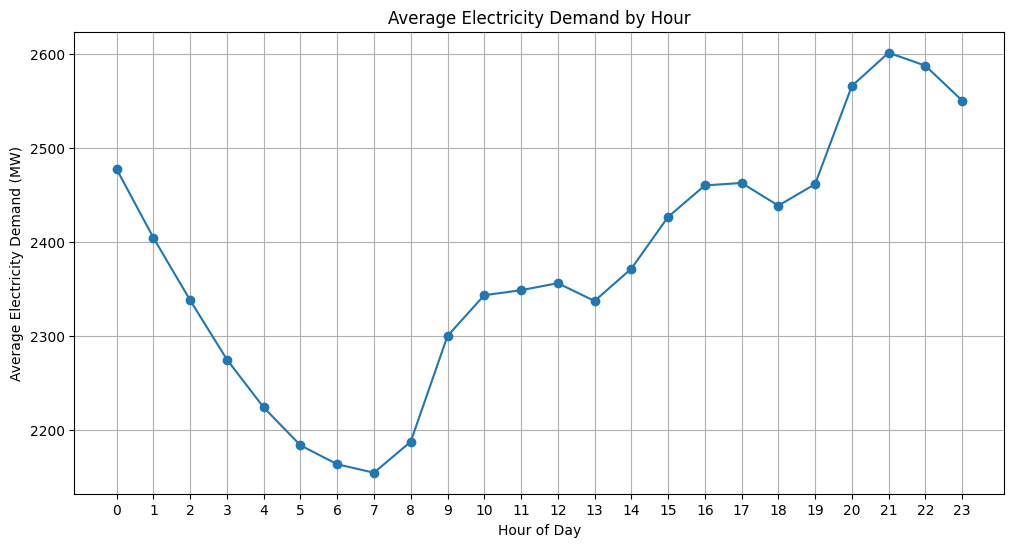

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_demand.sort_index().index,
    hourly_demand.sort_index().values,
    marker="o"
)

plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Electricity Demand (MW)")

plt.xticks(range(24))
plt.grid(True)

plt.show()

In [ ]:
weekday_avg = df[
    df["is_weekend"] == 0
]["active_power_mw"].mean()

weekend_avg = df[
    df["is_weekend"] == 1
]["active_power_mw"].mean()

print("Average Weekday Demand :", round(weekday_avg, 2), "MW")
print("Average Weekend Demand :", round(weekend_avg, 2), "MW")

Average Weekday Demand : 2416.45 MW
Average Weekend Demand : 2274.07 MW


In [ ]:
difference_percent = (
    (weekday_avg - weekend_avg)
    / weekend_avg
) * 100

print(
    "Weekday vs Weekend Difference:",
    round(difference_percent, 2),
    "%"
)

Weekday vs Weekend Difference: 6.26 %


In [ ]:
weekday_profile = (
    df[df["is_weekend"] == 0]
    .groupby("Hour")["active_power_mw"]
    .mean()
)

weekend_profile = (
    df[df["is_weekend"] == 1]
    .groupby("Hour")["active_power_mw"]
    .mean()
)

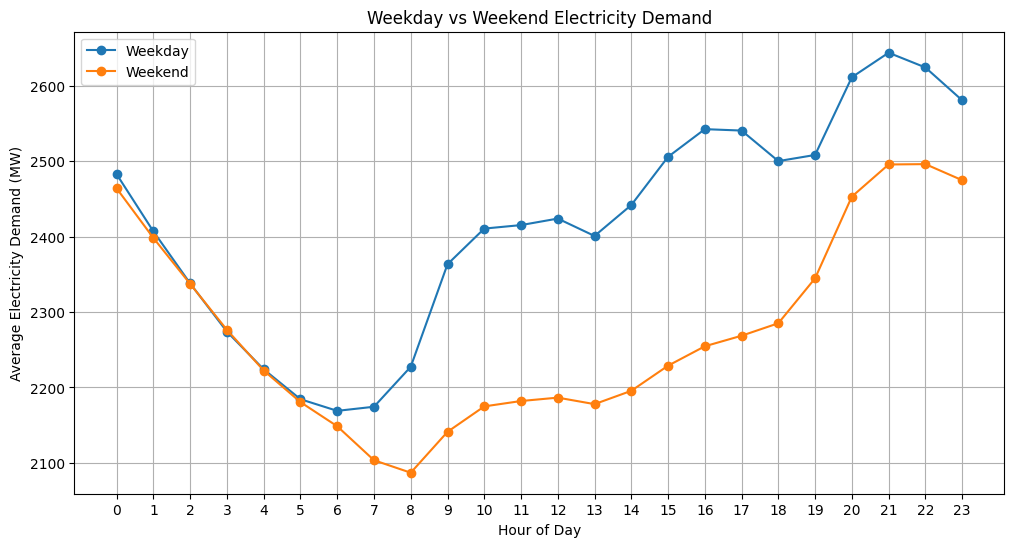

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    weekday_profile.index,
    weekday_profile.values,
    marker="o",
    label="Weekday"
)

plt.plot(
    weekend_profile.index,
    weekend_profile.values,
    marker="o",
    label="Weekend"
)

plt.title("Weekday vs Weekend Electricity Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Average Electricity Demand (MW)")

plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
temperature_corr = df[
    [
        "active_power_mw",
        "apparent_temperature_c"
    ]
].corr()

print(temperature_corr)

                        active_power_mw  apparent_temperature_c
active_power_mw                1.000000                0.549357
apparent_temperature_c         0.549357                1.000000


In [ ]:
corr_value = temperature_corr.loc[
    "active_power_mw",
    "apparent_temperature_c"
]

print(
    "Temperature-Demand Correlation:",
    round(corr_value, 4)
)

Temperature-Demand Correlation: 0.5494


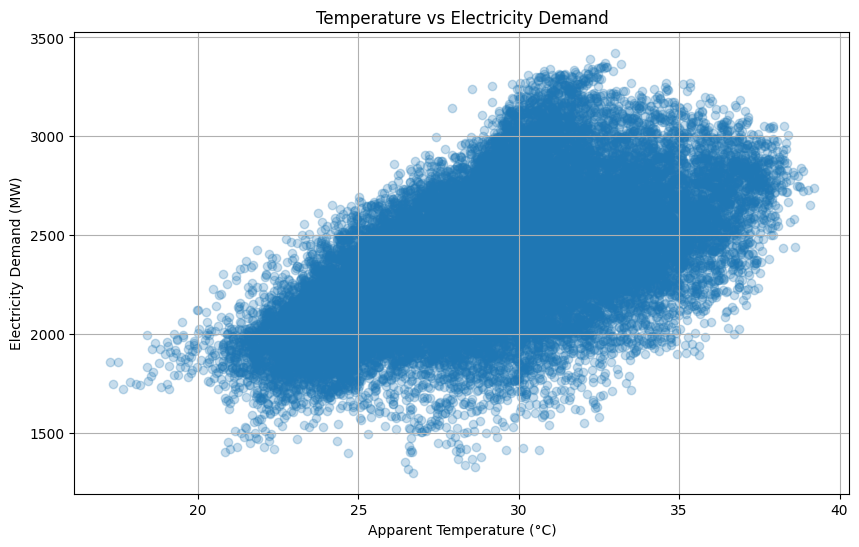

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["apparent_temperature_c"],
    df["active_power_mw"],
    alpha=0.25
)

plt.title("Temperature vs Electricity Demand")
plt.xlabel("Apparent Temperature (°C)")
plt.ylabel("Electricity Demand (MW)")

plt.grid(True)

plt.show()

In [ ]:
# Daily demand profile

daily_demand = (
    df.set_index("Date_Time")
      .resample("D")["active_power_mw"]
      .agg(["mean", "max", "min"])
)

daily_demand.columns = [
    "Average_Demand",
    "Peak_Demand",
    "Minimum_Demand"
]

print("Daily demand profile:")
display(daily_demand.head())

Daily demand profile:


,Average_Demand,Peak_Demand,Minimum_Demand
Date_Time,,,
2021-01-02,1555.340567,1804.591603,1404.610466
2021-01-03,1575.989769,1865.846157,1419.552518
2021-01-04,1666.135777,1963.540928,1479.308012
2021-01-05,1811.857260,2121.827083,1497.268371
2021-01-06,1864.326017,2089.316129,1619.123757


In [ ]:
top_days = daily_demand.sort_values(
    "Peak_Demand",
    ascending=False
).head(10)

display(top_days)

,Average_Demand,Peak_Demand,Minimum_Demand
Date_Time,,,
2024-10-09,3033.935383,3422.594406,2683.857552
2024-10-10,3088.365568,3367.841518,2762.371368
2024-09-18,3032.685741,3355.437842,2680.720206
2024-10-11,3061.679628,3351.378387,2725.313145
2024-09-19,3066.752775,3345.620247,2738.551923
2024-09-16,2988.169637,3344.320372,2638.583248
2024-08-28,3025.333033,3339.670286,2689.729756
2024-09-13,3042.337194,3328.130145,2689.706627
2024-08-19,2928.197933,3325.344763,2525.740445


In [ ]:
weekly_demand = (
    df.set_index("Date_Time")
      .resample("W")["active_power_mw"]
      .mean()
)

print("Number of weeks:", len(weekly_demand))

display(weekly_demand.head())

Number of weeks: 210


,active_power_mw
Date_Time,
2021-01-03,1565.884841
2021-01-10,1819.028486
2021-01-17,1935.492095
2021-01-24,1910.703841
2021-01-31,1848.077631


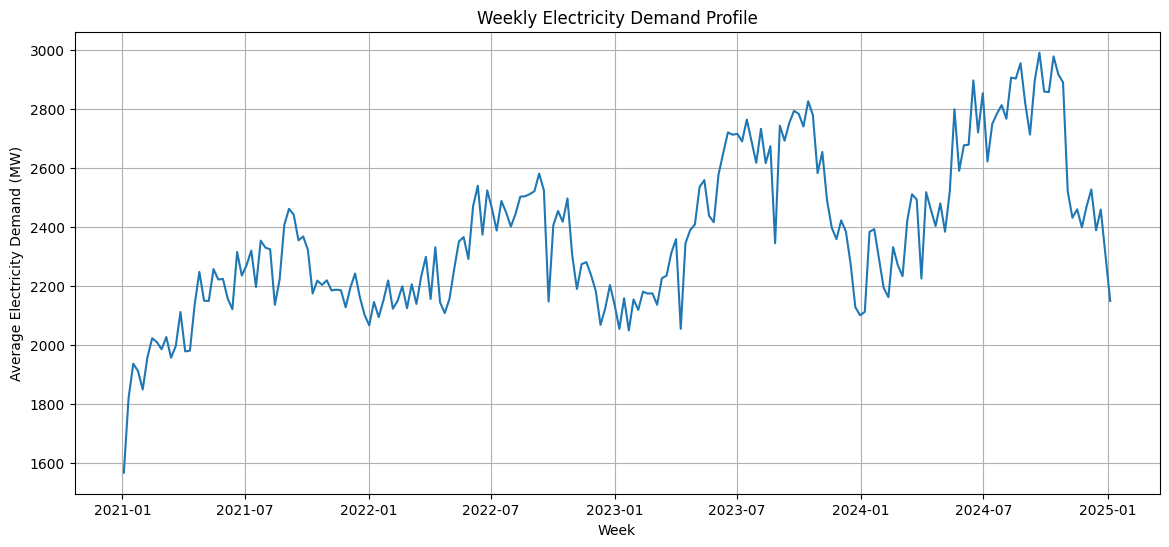

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    weekly_demand.index,
    weekly_demand.values
)

plt.title("Weekly Electricity Demand Profile")
plt.xlabel("Week")
plt.ylabel("Average Electricity Demand (MW)")

plt.grid(True)

plt.show()

In [ ]:
# Calculate 24-hour rolling statistics

df["rolling_mean_24h"] = (
    df["active_power_mw"]
      .rolling(window=24)
      .mean()
)

df["rolling_std_24h"] = (
    df["active_power_mw"]
      .rolling(window=24)
      .std()
)

In [ ]:
df["z_score"] = (
    (df["active_power_mw"] - df["rolling_mean_24h"])
    / df["rolling_std_24h"]
)

In [ ]:
spikes = df[
    df["z_score"] > 3
].copy()

print("Number of unusual demand spikes:", len(spikes))

display(
    spikes[
        [
            "Date_Time",
            "active_power_mw",
            "rolling_mean_24h",
            "z_score"
        ]
    ].sort_values(
        "z_score",
        ascending=False
    )
)

Number of unusual demand spikes: 3


,Date_Time,active_power_mw,rolling_mean_24h,z_score
15033,2022-09-20 10:00:00,1937.305685,1471.026655,3.262037
15032,2022-09-20 09:00:00,1772.030993,1450.910814,3.123584
5361,2021-08-13 10:00:00,2298.665716,2033.934558,3.004196


In [ ]:
heatmap_data = df.pivot_table(
    index="Day_of_Week",
    columns="Hour",
    values="active_power_mw",
    aggfunc="mean"
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

heatmap_data = heatmap_data.reindex(day_order)

display(heatmap_data)

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day_of_Week,,,,,,,,,,,,,,,,,,,,,
Monday,2404.542663,2338.547954,2275.402612,2214.077415,2163.310482,2125.080855,2113.798463,2129.571918,2192.289547,2336.551763,...,2440.379653,2500.642555,2535.764644,2535.368335,2495.036134,2501.674294,2607.878740,2646.892418,2631.155301,2585.150514
Tuesday,2499.730396,2418.689875,2346.703979,2282.710196,2233.515925,2193.895268,2177.736366,2182.398380,2234.207222,2371.836027,...,2442.309805,2510.153548,2552.005063,2555.704141,2512.433981,2512.181371,2614.757435,2651.011778,2635.158748,2591.090068
Wednesday,2509.345720,2429.861800,2358.901700,2293.646132,2243.845819,2203.236456,2187.696547,2190.482980,2241.016475,2372.605389,...,2438.268928,2503.511527,2543.705219,2540.300262,2501.067863,2509.023670,2611.447231,2648.011973,2626.915131,2582.213763
Thursday,2498.260702,2422.043820,2352.331511,2287.439715,2237.431037,2197.853500,2180.063777,2183.785355,2233.220107,2365.385164,...,2441.496513,2503.573287,2540.283117,2537.176308,2497.031155,2507.164647,2610.723274,2638.197868,2621.609218,2582.033863
Friday,2501.743242,2425.355286,2356.607670,2292.234859,2242.563182,2202.374129,2186.050489,2186.283539,2236.834292,2370.783174,...,2447.146462,2511.148127,2540.770187,2534.616317,2495.108767,2511.470167,2611.973266,2635.049661,2606.673776,2563.400322
Saturday,2493.871971,2420.114513,2354.442934,2292.565478,2239.627441,2199.144958,2169.971171,2136.011211,2142.566598,2228.954387,...,2269.475684,2308.807342,2336.482954,2348.845123,2360.392445,2411.276373,2508.132308,2535.865575,2518.221734,2487.137676
Sunday,2434.160524,2376.213192,2320.104050,2260.171877,2205.325136,2162.059194,2127.216777,2071.092335,2031.425964,2053.454312,...,2121.694258,2149.012973,2172.788977,2188.399324,2209.954656,2278.265799,2398.018223,2455.478878,2474.089026,2462.555812


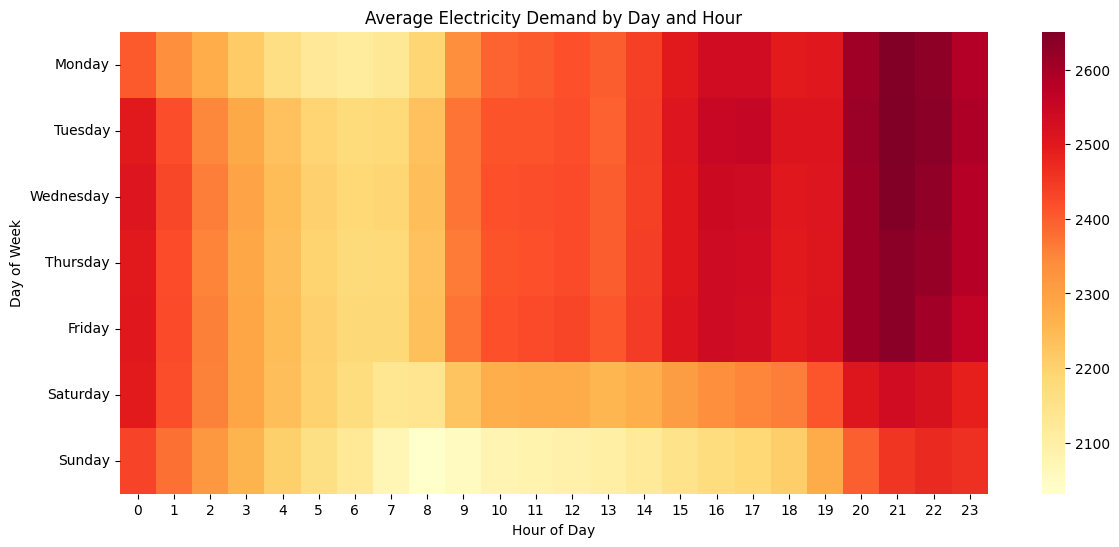

In [ ]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=False
)

plt.title("Average Electricity Demand by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

In [ ]:
lag_columns = [
    col for col in df.columns
    if "active_power_lag" in col
]

print("Number of lag features:", len(lag_columns))
print(lag_columns)

Number of lag features: 24
['active_power_lag_1h', 'active_power_lag_2h', 'active_power_lag_3h', 'active_power_lag_4h', 'active_power_lag_5h', 'active_power_lag_6h', 'active_power_lag_7h', 'active_power_lag_8h', 'active_power_lag_9h', 'active_power_lag_10h', 'active_power_lag_11h', 'active_power_lag_12h', 'active_power_lag_13h', 'active_power_lag_14h', 'active_power_lag_15h', 'active_power_lag_16h', 'active_power_lag_17h', 'active_power_lag_18h', 'active_power_lag_19h', 'active_power_lag_20h', 'active_power_lag_21h', 'active_power_lag_22h', 'active_power_lag_23h', 'active_power_lag_24h']


In [ ]:
features = [
    "apparent_temperature_c",
    "cloud_cover_percent",
    "month",
    "hour",
    "is_holiday",
    "is_weekend",
    "is_school_vacation",
    "Day_of_Week_Num"
] + lag_columns

print("Total features:", len(features))
print(features)

Total features: 32
['apparent_temperature_c', 'cloud_cover_percent', 'month', 'hour', 'is_holiday', 'is_weekend', 'is_school_vacation', 'Day_of_Week_Num', 'active_power_lag_1h', 'active_power_lag_2h', 'active_power_lag_3h', 'active_power_lag_4h', 'active_power_lag_5h', 'active_power_lag_6h', 'active_power_lag_7h', 'active_power_lag_8h', 'active_power_lag_9h', 'active_power_lag_10h', 'active_power_lag_11h', 'active_power_lag_12h', 'active_power_lag_13h', 'active_power_lag_14h', 'active_power_lag_15h', 'active_power_lag_16h', 'active_power_lag_17h', 'active_power_lag_18h', 'active_power_lag_19h', 'active_power_lag_20h', 'active_power_lag_21h', 'active_power_lag_22h', 'active_power_lag_23h', 'active_power_lag_24h']


In [ ]:
X = df[features]
y = df["active_power_mw"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (35039, 32)
y shape: (35039,)


In [ ]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


In [ ]:
split = int(len(df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 28031
Testing samples: 7008


In [ ]:
print("Training period:")
print(df["Date_Time"].iloc[0])
print("to")
print(df["Date_Time"].iloc[split - 1])

print("\nTesting period:")
print(df["Date_Time"].iloc[split])
print("to")
print(df["Date_Time"].iloc[-1])

Training period:
2021-01-02 01:00:00
to
2024-03-14 23:00:00

Testing period:
2024-03-15 00:00:00
to
2024-12-31 23:00:00


In [ ]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Predictions generated!")
print(y_pred[:10])

Predictions generated!
[2709.228  2648.9695 2572.7537 2477.811  2397.6343 2357.4446 2346.5325
 2338.991  2386.9883 2417.9321]


In [ ]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("========== XGBOOST RESULTS ==========")
print("MAE :", round(mae, 2), "MW")
print("RMSE:", round(rmse, 2), "MW")
print("R²  :", round(r2, 4))
print("======================================")

========== XGBOOST RESULTS ==========
MAE : 33.0 MW
RMSE: 49.37 MW
R²  : 0.9733


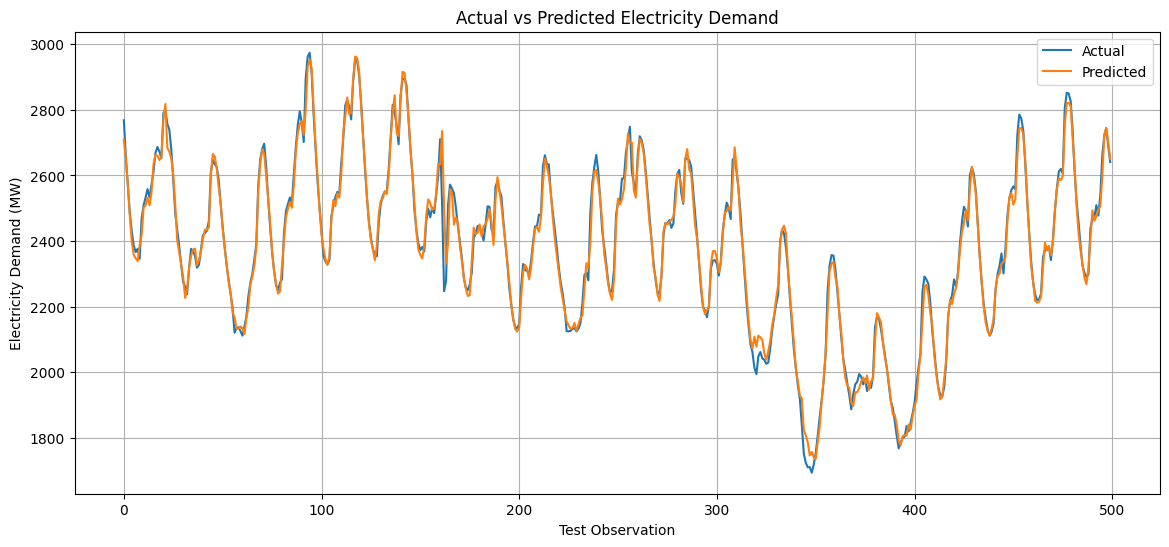

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    y_pred[:500],
    label="Predicted"
)

plt.title("Actual vs Predicted Electricity Demand")
plt.xlabel("Test Observation")
plt.ylabel("Electricity Demand (MW)")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
top_features = importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 15 XGBoost Features")

plt.show()

NameError: name 'importance' is not defined

In [ ]:
# Create feature importance DataFrame

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance.head(15))

,Feature,Importance
8,active_power_lag_1h,0.743994
9,active_power_lag_2h,0.136329
31,active_power_lag_24h,0.027642
3,hour,0.018271
30,active_power_lag_23h,0.017548
5,is_weekend,0.008545
10,active_power_lag_3h,0.005465
12,active_power_lag_5h,0.005220
7,Day_of_Week_Num,0.003079
0,apparent_temperature_c,0.002616


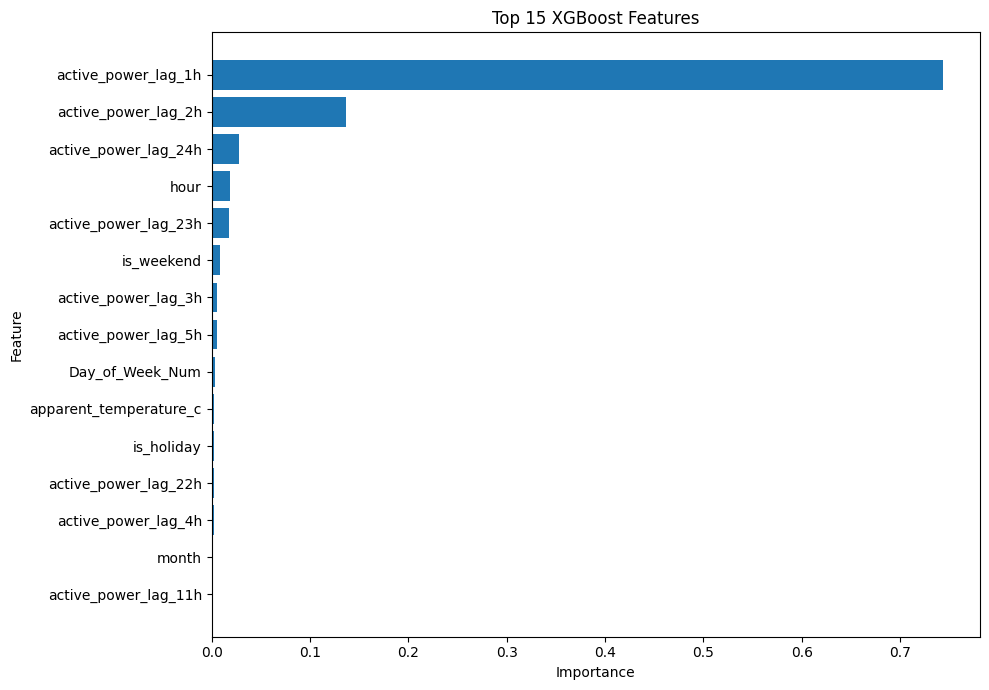

In [ ]:
# Top 15 XGBoost features

top_features = (
    importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features")

plt.tight_layout()
plt.show()

In [ ]:
results = pd.DataFrame({
    "Date_Time": df.loc[X_test.index, "Date_Time"].values,
    "Actual_Demand_MW": y_test.values,
    "Predicted_Demand_MW": y_pred
})

results["Error_MW"] = (
    results["Actual_Demand_MW"] -
    results["Predicted_Demand_MW"]
)

display(results.head(10))

,Date_Time,Actual_Demand_MW,Predicted_Demand_MW,Error_MW
0,2024-03-15 00:00:00,2768.380463,2709.228027,59.152436
1,2024-03-15 01:00:00,2658.556074,2648.969482,9.586592
2,2024-03-15 02:00:00,2571.061664,2572.753662,-1.691998
3,2024-03-15 03:00:00,2486.404074,2477.811035,8.593039
4,2024-03-15 04:00:00,2429.680500,2397.634277,32.046223
5,2024-03-15 05:00:00,2386.130464,2357.444580,28.685884
6,2024-03-15 06:00:00,2365.903224,2346.532471,19.370753
7,2024-03-15 07:00:00,2376.277512,2338.990967,37.286545
8,2024-03-15 08:00:00,2345.733244,2386.988281,-41.255037
9,2024-03-15 09:00:00,2468.303217,2417.932129,50.371088


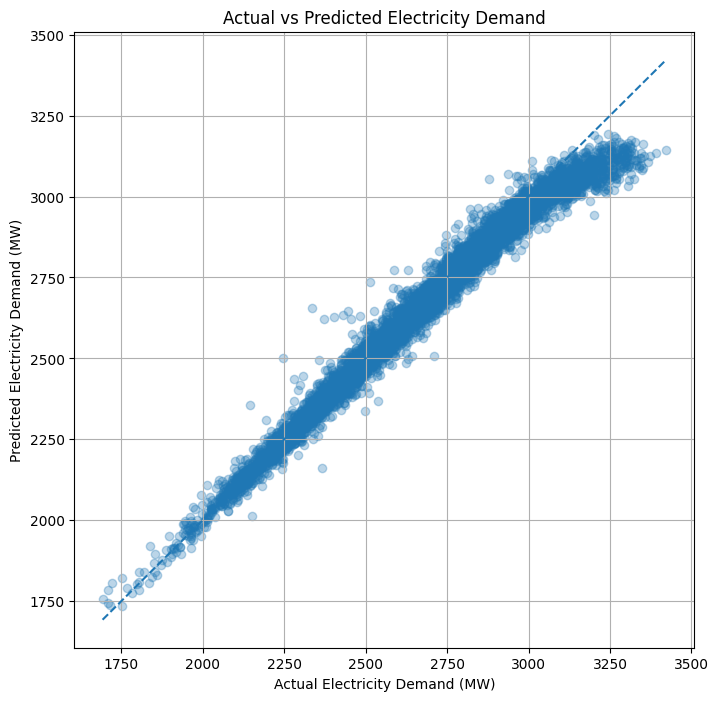

In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

# Perfect prediction line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Electricity Demand (MW)")
plt.ylabel("Predicted Electricity Demand (MW)")
plt.title("Actual vs Predicted Electricity Demand")

plt.grid(True)
plt.show()

In [ ]:
results.to_csv(
    "xgboost_predictions.csv",
    index=False
)

print("Prediction results saved successfully!")

Prediction results saved successfully!


In [ ]:
model_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R² Score"
    ],
    "Value": [
        mae,
        rmse,
        r2
    ]
})

display(model_results)

,Metric,Value
0,MAE,32.996016
1,RMSE,49.374119
2,R² Score,0.973286


In [ ]:
peak_row = df.loc[
    df["active_power_mw"].idxmax()
]

print("Peak demand:", round(peak_row["active_power_mw"], 2), "MW")
print("Peak date:", peak_row["Date_Time"])
print("Peak hour:", peak_row["Hour"])
print("Peak day:", peak_row["Day_of_Week"])

Peak demand: 3422.59 MW
Peak date: 2024-10-09 21:00:00
Peak hour: 21
Peak day: Wednesday


In [ ]:
hourly_profile = (
    df.groupby("Hour")["active_power_mw"]
    .mean()
)

highest_hour = hourly_profile.idxmax()

print(
    "Highest average-demand hour:",
    highest_hour
)

print(
    "Average demand:",
    round(hourly_profile.max(), 2),
    "MW"
)

Highest average-demand hour: 21
Average demand: 2601.42 MW


In [ ]:
weekday_avg = df[
    df["is_weekend"] == 0
]["active_power_mw"].mean()

weekend_avg = df[
    df["is_weekend"] == 1
]["active_power_mw"].mean()

print("Weekday:", round(weekday_avg, 2), "MW")
print("Weekend:", round(weekend_avg, 2), "MW")

Weekday: 2416.45 MW
Weekend: 2274.07 MW


In [ ]:
temperature_corr = df[
    [
        "active_power_mw",
        "apparent_temperature_c"
    ]
].corr().iloc[0, 1]

print(
    "Temperature correlation:",
    round(temperature_corr, 4)
)

Temperature correlation: 0.5494


# Key Insights

### 1. Peak Electricity Demand
The maximum recorded electricity demand was approximately 3422.59 MW.
The peak occurred during the evening period, highlighting the importance of evening capacity planning.

### 2. Daily Demand Pattern
Electricity demand varies significantly throughout the day. Demand is relatively lower during the early morning hours and increases during the daytime and evening.

### 3. Evening Peak
The highest average hourly demand occurs around the evening period. This period should receive particular attention when planning generation and reserve capacity.

### 4. Weekday vs Weekend
Weekday electricity demand is generally higher than weekend demand. The difference becomes more visible during daytime and evening hours.

### 5. Temperature Effect
The analysis shows a positive association between apparent temperature and electricity demand. Higher-temperature periods are generally associated with higher electricity consumption.

### 6. Unusual Demand Spikes
Statistical analysis using a 24-hour rolling baseline identified unusually high demand observations. These spikes should be investigated against weather, holidays and operational events.

### 7. XGBoost Performance
The XGBoost model provides strong forecasting performance on the chronological test dataset, with MAE, RMSE and R² used to evaluate prediction quality.

# Practical Action Plan for the Energy Company

### 1. Prepare for Evening Peaks
Maintain sufficient generation and reserve capacity before the high-demand evening period.

### 2. Temperature-Based Planning
Use temperature forecasts as an additional input when estimating future electricity requirements.

### 3. Short-Term Demand Forecasting
Use the XGBoost model with recent demand, weather and calendar information to forecast upcoming electricity demand.

### 4. Monitor Demand Spikes
Automatically flag statistically unusual demand increases and investigate the underlying operational or environmental causes.

### 5. Weekday Capacity Planning
Because weekday demand is generally higher than weekend demand, capacity planning should consider separate weekday and weekend demand profiles.

### 6. Improve Data Collection
Future versions of the system should include region, humidity, wind speed, generation sources and outage information to improve forecasting and regional capacity planning.

# Conclusion

This project analyzed hourly electricity demand patterns using historical electricity, weather and calendar data.

The analysis identified daily and weekly demand patterns, peak-demand periods, differences between weekday and weekend consumption, the relationship between temperature and electricity demand, and unusual demand spikes.

An XGBoost regression model was then developed to predict electricity demand using weather, calendar and historical demand features. The model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and R² Score.

The results demonstrate how data analytics and machine learning can support electricity providers in short-term demand forecasting and capacity planning.

In [ ]:
import joblib

joblib.dump(
    model,
    "xgboost_energy_demand.pkl"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!
